<h1>🎬 Hybrid Recommendation System </h1>
<h4 style="color:#555; margin-top:-8px;">
Content-Based and User-Based Collaborative Filtering</h4>

<hr style="border:1px solid #ddd;">


In [342]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>  📂
    Dataset Overview </h3>
</div>

**Competition:** IMDB Movie Ratings Dataset

**File Used:** `movie_data.csv`  
**Dataset Source:** Kaggle  
**Url:** https://www.kaggle.com/datasets/thedevastator/imdb-movie-ratings-dataset

**Raw Features** 
| Feature                | Description                                                                                          |
| ---------------------- | ---------------------------------------------------------------------------------------------------- |
| `index`                | Unique row identifier for each movie entry.                                                          |
| `director_name`        | Name of the movie’s director. Useful for content similarity features.                                |
| `duration`             | Length of the movie in minutes. Numerical feature.                                                   |
| `actor_2_name`         | Name of the second listed main actor. Can be used for similarity modeling.                           |
| `genres`               | Categories describing the movie type (e.g., Action, Drama). Key feature for content-based filtering. |
| `actor_1_name`         | Name of the primary actor. Useful for content similarity.                                            |
| `movie_title`          | Official movie title. Used for display in recommendations.                                           |
| `num_voted_users`      | Total number of IMDb users who rated the movie. Indicates popularity.                                |
| `actor_3_name`         | Name of the third listed main actor. Optional content feature.                                       |
| `movie_imdb_link`      | Direct IMDb URL for the movie. Useful for reference or UI linking.                                   |
| `num_user_for_reviews` | Number of users who wrote reviews. Popularity/engagement metric.                                     |
| `language`             | Primary language of the movie. Can be used for filtering.                                            |
| `country`              | Country of production. Optional categorical feature.                                                 |
| `title_year`           | Year the movie was released. Useful for temporal filtering.                                          |
| `imdb_score`           | IMDb rating score (1–10 scale). Can be used for ranking or weighting recommendations.                |



**Importing the Required Files**

In [4]:
df = pd.read_csv("movie_data.csv")

In [5]:
df.columns

Index(['index', 'director_name', 'duration', 'actor_2_name', 'genres',
       'actor_1_name', 'movie_title', 'num_voted_users', 'actor_3_name',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'title_year', 'imdb_score'],
      dtype='object')

In [6]:
df.head()

,index,director_name,duration,actor_2_name,genres,actor_1_name,movie_title,num_voted_users,actor_3_name,movie_imdb_link,num_user_for_reviews,language,country,title_year,imdb_score
0,0,James Cameron,178.0,Joel David Moore,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,Wes Studi,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,2009.0,7.9
1,1,Gore Verbinski,169.0,Orlando Bloom,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,Jack Davenport,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,2007.0,7.1
2,2,Sam Mendes,148.0,Rory Kinnear,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,Stephanie Sigman,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,2015.0,6.8
3,3,Christopher Nolan,164.0,Christian Bale,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,Joseph Gordon-Levitt,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,2012.0,8.5
4,4,Doug Walker,NaN,Rob Walker,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,7.1


In [ ]:
#find cosine similarity for different movie titles and recommend to users 

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Data Quality Check </h3>
</div>

In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5043 non-null   int64  
 1   director_name         4939 non-null   object 
 2   duration              5028 non-null   float64
 3   actor_2_name          5030 non-null   object 
 4   genres                5043 non-null   object 
 5   actor_1_name          5036 non-null   object 
 6   movie_title           5043 non-null   object 
 7   num_voted_users       5043 non-null   int64  
 8   actor_3_name          5020 non-null   object 
 9   movie_imdb_link       5043 non-null   object 
 10  num_user_for_reviews  5022 non-null   float64
 11  language              5029 non-null   object 
 12  country               5038 non-null   object 
 13  title_year            4935 non-null   float64
 14  imdb_score            5043 non-null   float64
dtypes: float64(4), int64(

In [11]:
df.describe(include='all')

,index,director_name,duration,actor_2_name,genres,actor_1_name,movie_title,num_voted_users,actor_3_name,movie_imdb_link,num_user_for_reviews,language,country,title_year,imdb_score
count,5043.000000,4939,5028.000000,5030,5043,5036,5043,5.043000e+03,5020,5043,5022.000000,5029,5038,4935.000000,5043.000000
unique,NaN,2398,NaN,3032,914,2097,4917,NaN,3521,4919,NaN,46,65,NaN,NaN
top,NaN,Steven Spielberg,NaN,Morgan Freeman,Drama,Robert De Niro,King Kong,NaN,Steve Coogan,http://www.imdb.com/title/tt0232500/?ref_=fn_t...,NaN,English,USA,NaN,NaN
freq,NaN,26,NaN,20,236,49,3,NaN,8,3,NaN,4704,3807,NaN,NaN
mean,2521.000000,NaN,107.201074,NaN,NaN,NaN,NaN,8.366816e+04,NaN,NaN,272.770808,NaN,NaN,2002.470517,6.442138
std,1455.933034,NaN,25.197441,NaN,NaN,NaN,NaN,1.384853e+05,NaN,NaN,377.982886,NaN,NaN,12.474599,1.125116
min,0.000000,NaN,7.000000,NaN,NaN,NaN,NaN,5.000000e+00,NaN,NaN,1.000000,NaN,NaN,1916.000000,1.600000
25%,1260.500000,NaN,93.000000,NaN,NaN,NaN,NaN,8.593500e+03,NaN,NaN,65.000000,NaN,NaN,1999.000000,5.800000
50%,2521.000000,NaN,103.000000,NaN,NaN,NaN,NaN,3.435900e+04,NaN,NaN,156.000000,NaN,NaN,2005.000000,6.600000
75%,3781.500000,NaN,118.000000,NaN,NaN,NaN,NaN,9.630900e+04,NaN,NaN,326.000000,NaN,NaN,2011.000000,7.200000


In [16]:
df.isna().sum().sort_values(ascending=False)

title_year              108
director_name           104
actor_3_name             23
num_user_for_reviews     21
duration                 15
language                 14
actor_2_name             13
actor_1_name              7
country                   5
index                     0
genres                    0
movie_title               0
num_voted_users           0
movie_imdb_link           0
imdb_score                0
dtype: int64

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
We can observe from here that there are a lot of data missing in this file. For further analysis, I will focus on non missing data values or fill the missing values with X. 
    

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 🧹Data Cleaning & Preprocessing</h3>
</div>

Data Types & Validation Numeric and categorical features are verified to ensure correct downstream analysis. Incorrect data types can lead to invalid probability estimates, scaling errors, and misleading model behavior. Therefore, explicit data type validation is performed prior to exploratory analysis and feature engineering

**Explicitly Separate Numeric & Categorical Features**

In [18]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['index', 'duration', 'num_voted_users', 'num_user_for_reviews', 'title_year', 'imdb_score']
Categorical Features: ['director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'movie_imdb_link', 'language', 'country']


**Validate Numeric Ranges (Catch Silent Errors)**

In [19]:
df[numeric_features].describe()

,index,duration,num_voted_users,num_user_for_reviews,title_year,imdb_score
count,5043.000000,5028.000000,5.043000e+03,5022.000000,4935.000000,5043.000000
mean,2521.000000,107.201074,8.366816e+04,272.770808,2002.470517,6.442138
std,1455.933034,25.197441,1.384853e+05,377.982886,12.474599,1.125116
min,0.000000,7.000000,5.000000e+00,1.000000,1916.000000,1.600000
25%,1260.500000,93.000000,8.593500e+03,65.000000,1999.000000,5.800000
50%,2521.000000,103.000000,3.435900e+04,156.000000,2005.000000,6.600000
75%,3781.500000,118.000000,9.630900e+04,326.000000,2011.000000,7.200000
max,5042.000000,511.000000,1.689764e+06,5060.000000,2016.000000,9.500000


**Validate Categorical Consistency**

##### Unique Values for Cateogrical Columns

In [332]:
for col in categorical_features:
    print(col, ":", df[col].nunique())

director_name : 2399
actor_2_name : 3033
genres : 1
actor_1_name : 2098
movie_title : 4917
actor_3_name : 3522
movie_imdb_link : 4919
language : 47
country : 66


In [337]:
def validate_category(col):
    print(f"\n--- {col} ---")
    print("Unique:", df[col].nunique())
    print(imdb[col].value_counts().head(10))

validate_category('language')
validate_category('country')
validate_category('genres')


--- language ---
Unique: 47
language
English      4704
French         73
Spanish        40
Hindi          28
Mandarin       26
German         19
Japanese       18
Unknown        14
Cantonese      11
Italian        11
Name: count, dtype: int64

--- country ---
Unique: 66
country
Usa          3807
Uk            448
France        154
Canada        126
Germany        97
Australia      55
India          34
Spain          33
China          30
Japan          23
Name: count, dtype: int64

--- genres ---
Unique: 1
genres
Drama                          236
Comedy                         209
Comedy|Drama                   191
Comedy|Drama|Romance           187
Comedy|Romance                 158
Drama|Romance                  152
Crime|Drama|Thriller           101
Horror                          71
Action|Crime|Drama|Thriller     68
Action|Crime|Thriller           65
Name: count, dtype: int64


<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
Data quality checks are critical to avoid biased probability estimates and
misleading conclusions. Ensuring correct data types prevents numeric operations
from being applied to categorical fields and guarantees that probability
calculations reflect true feature behavior rather than data encoding artifacts.
</div>

In [23]:
df.duplicated().sum()

np.int64(0)

In [30]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()

In [32]:
df_clean[categorical_features] = df_clean[categorical_features].fillna("Unknown")

In [38]:
df_clean[numeric_features] = df_clean[numeric_features].fillna(df_clean[numeric_features].median())

In [39]:
df_clean.isna().sum()

index                   0
director_name           0
duration                0
actor_2_name            0
genres                  0
actor_1_name            0
movie_title             0
num_voted_users         0
actor_3_name            0
movie_imdb_link         0
num_user_for_reviews    0
language                0
country                 0
title_year              0
imdb_score              0
dtype: int64

In [366]:
def clean_movie_titles(df, column='movie_title'):
    df[column] = (df[column].astype(str).str.replace('\xa0', '', regex=False).str.replace(r'\s+', ' ', regex=True).str.strip())        
    return df

In [367]:
df_clean = clean_movie_titles(df_clean)

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Exploratory Data Analysis</h3>
</div>

In [369]:
imdb = df_clean.copy()

In [370]:
imdb.columns

Index(['index', 'director_name', 'duration', 'actor_2_name', 'genres',
       'actor_1_name', 'movie_title', 'num_voted_users', 'actor_3_name',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'title_year', 'imdb_score'],
      dtype='object')

#### Distribution of IMDB Scores

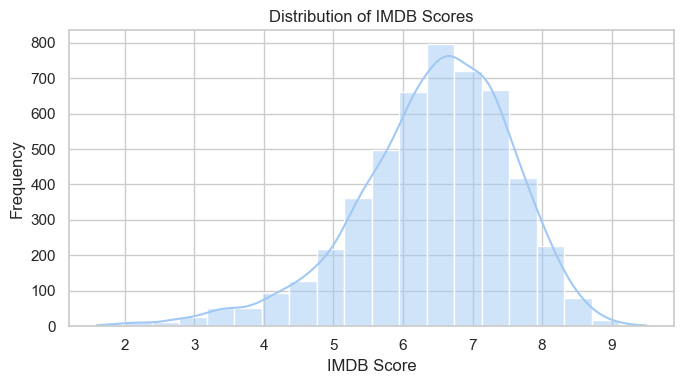

In [277]:
plt.figure(figsize=(7,4)) 
ax[0] = sns.histplot(data=imdb,x='imdb_score',bins=20,kde=True,color=sns.color_palette("pastel")[0])
ax[0].set_title("Distribution of IMDB Scores")
ax[0].set_xlabel("IMDB Score")
ax[0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 6px 12px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong> Analysis </strong> As you can see the data is rightly skewed so ratings alone may not be strong enough for strong recommendations

### Average IMDB Score Over Time

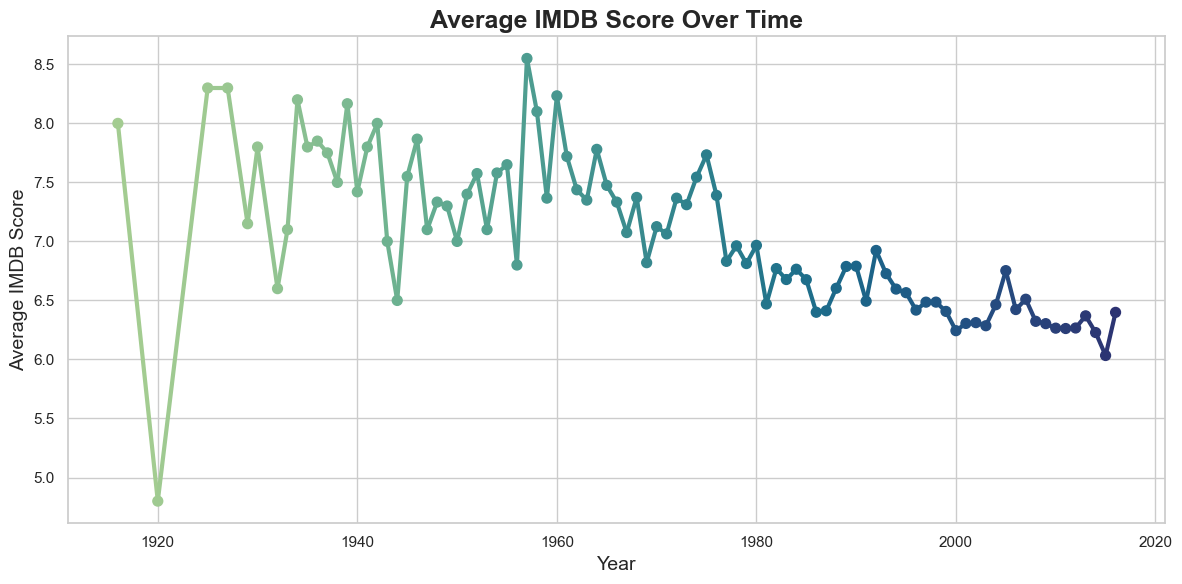

In [301]:
sns.set_theme(style="whitegrid")
year_avg = (imdb.groupby('title_year')['imdb_score'].mean().reset_index())
plt.figure(figsize=(12,6))
palette = sns.color_palette("crest", len(year_avg))
# Plot colorful line with markers
for i in range(len(year_avg)-1):
    plt.plot(year_avg['title_year'][i:i+2],year_avg['imdb_score'][i:i+2],color=palette[i],linewidth=3)
# Add scatter points
plt.scatter(year_avg['title_year'],year_avg['imdb_score'],c=palette,s=50)
plt.title("Average IMDB Score Over Time", fontsize=18, weight='bold')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average IMDB Score", fontsize=14)
plt.tight_layout()
plt.show()

### Movie by Genres


In [188]:
imdb['genres'] = imdb['genres'].str.split('|')

In [72]:
imdb_exploded = imdb.explode('genres')

In [141]:
genre_counts = imdb_exploded['genres'].value_counts()
genre_counts.columns = ['genres', 'movie_count']
top10 = genre_counts.head(10) 

In [164]:
genre_counts_num = imdb_exploded['genres'].value_counts().reset_index()
genre_counts_num.columns = ['genres', 'movie_count']
genre_counts_num = genre_counts_num.head(10)

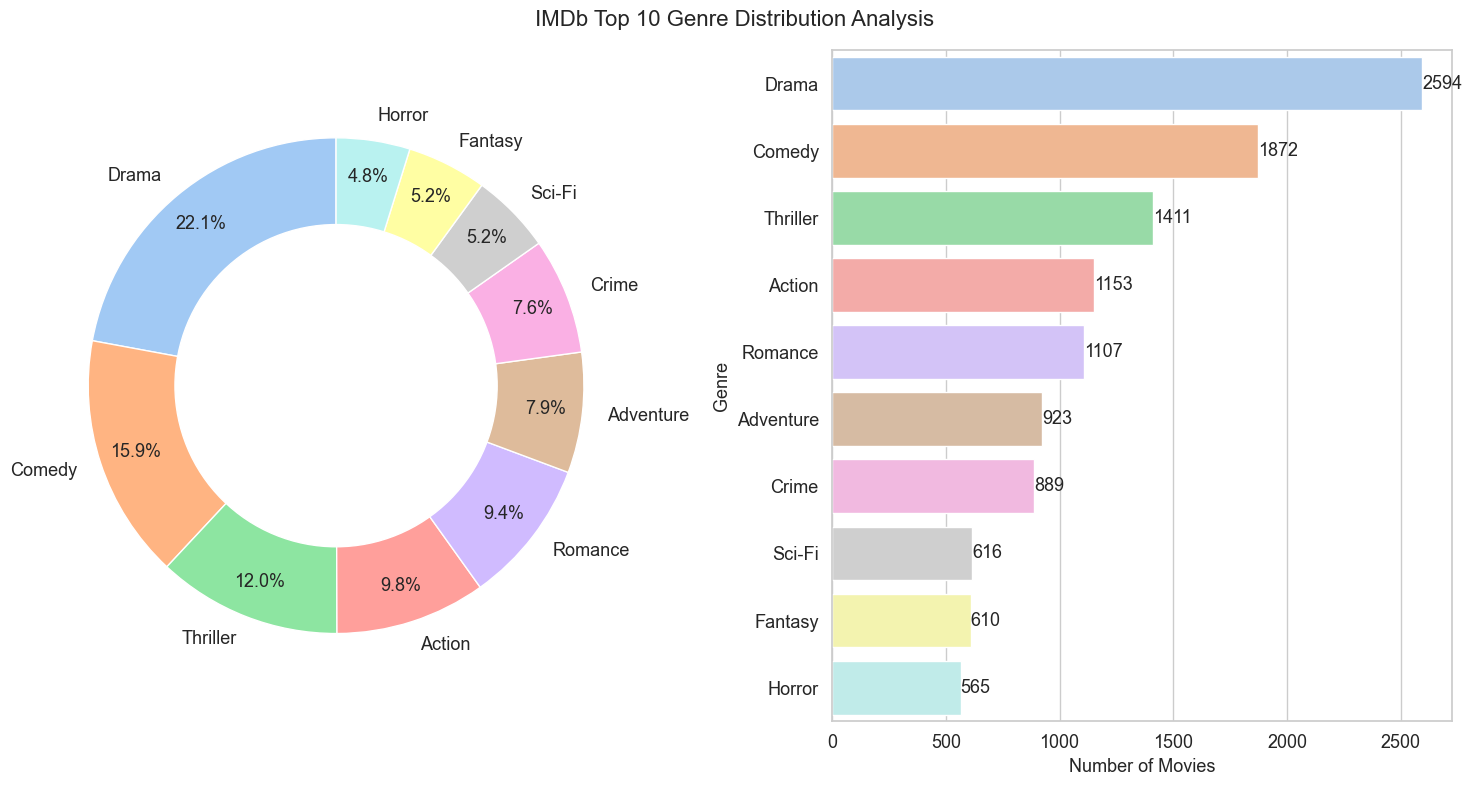

In [279]:
fig,ax = plt.subplots(1,2,figsize=(15,8))
colors = sns.color_palette("pastel", len(genre_counts))
fig.suptitle("IMDb Top 10 Genre Distribution Analysis", fontsize=16)
wedges, texts, autotexts = ax[0].pie(top10,labels=top10.index,autopct='%1.1f%%',startangle=90,pctdistance=0.85,colors=colors)
centre_circle = plt.Circle((0,0), 0.65, fc='white')
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(13)
ax[0].add_artist(centre_circle)
ax[1] = sns.barplot(data=genre_counts_num,y='genres',x='movie_count',hue='genres',palette='pastel')
for container in ax[1].containers:
    ax[1].bar_label(container,fontsize=13)
ax[1].set_xlabel("Number of Movies",fontsize=13)
ax[1].set_ylabel("Genre",fontsize=13)
ax[1].tick_params(axis='x', labelsize=13)
ax[1].tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()

### Average Rating by Genre

In [81]:
avg_genre = imdb_exploded.groupby('genres')['imdb_score'].mean().reset_index().sort_values(by='imdb_score',ascending=False)

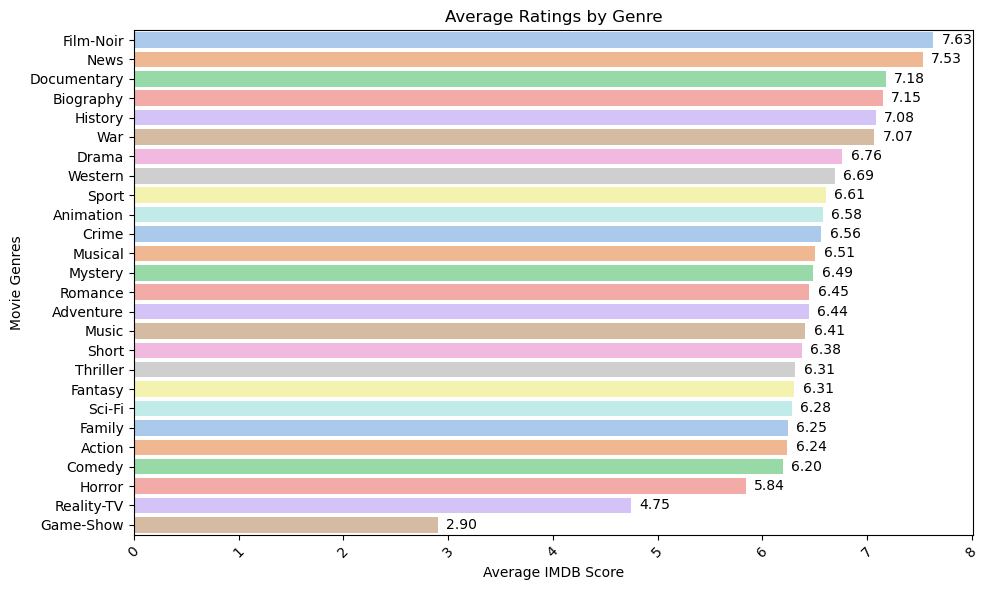

In [181]:
plt.figure(figsize=(10,6)) 
ax = sns.barplot(data=avg_genre,y='genres',x='imdb_score',hue='genres',palette='pastel')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f',padding=6)
plt.xticks(rotation=45)
plt.title ("Average Ratings by Genre")
plt.xlabel("Average IMDB Score") 
plt.ylabel("Movie Genres") 
plt.tight_layout()
plt.show()

### Most Popular Actor

In [201]:
popular_actor = imdb['actor_1_name'].value_counts().reset_index()
popular_actor.columns = ['actor', 'movie_count']
top10_actor = popular_actor.head(10) 

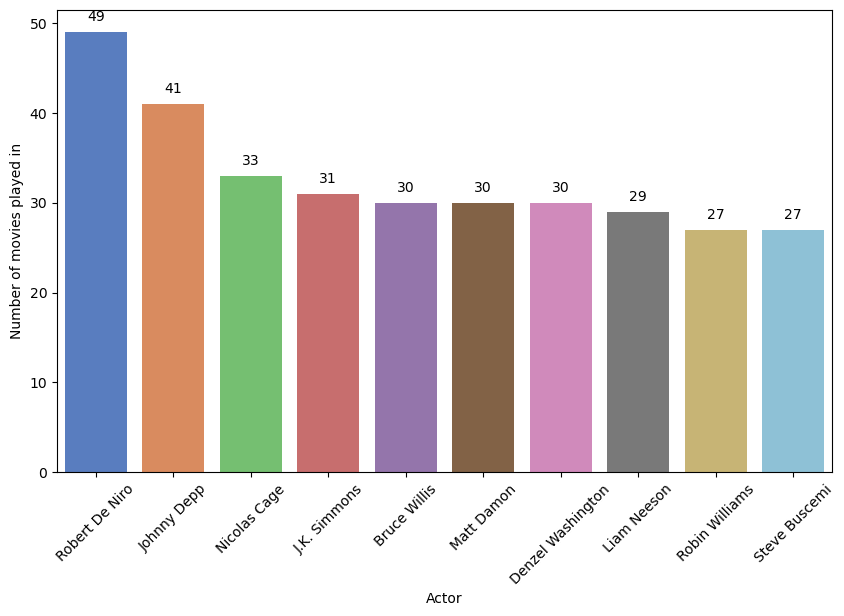

In [235]:
plt.figure(figsize=(10,6)) 
ax = sns.barplot(data=top10_actor,x='actor',y='movie_count',hue='actor',palette='muted')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f',padding=6)
plt.ylabel("Number of movies played in")
plt.xlabel("Actor")
plt.show()

### Top 10 Most Voted Movies

In [371]:
movie_voted = imdb.groupby('movie_title')['num_voted_users'].sum().sort_values(ascending=False).head(10).reset_index() 

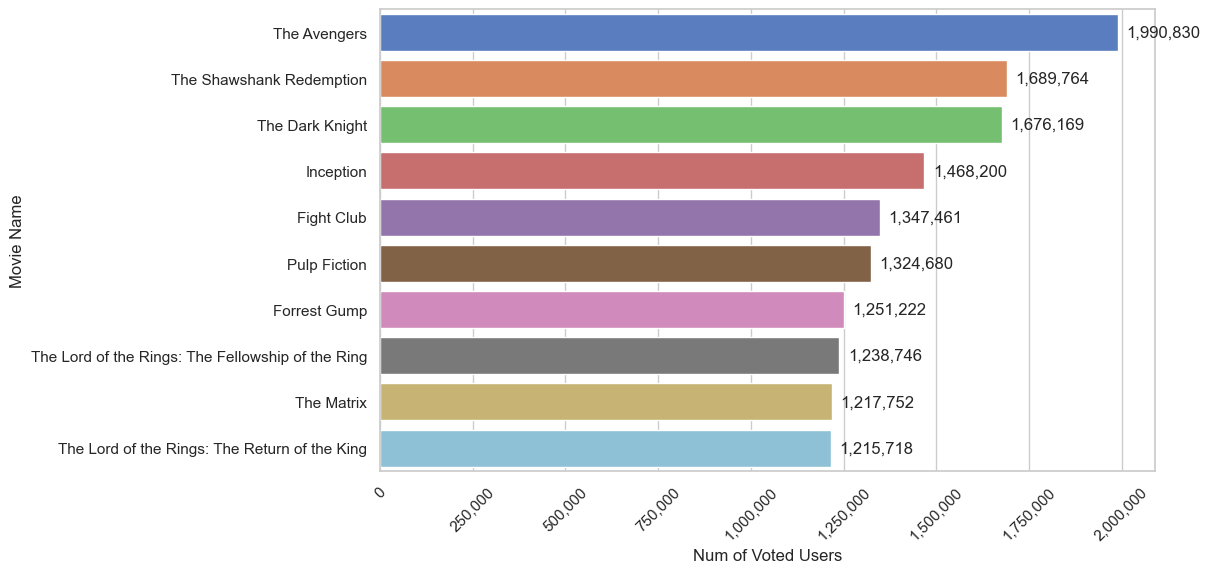

In [373]:
plt.figure(figsize=(10,6)) 
ax = sns.barplot(data=movie_voted,y='movie_title',x='num_voted_users',hue='movie_title',palette='muted')
plt.xticks(rotation=45)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}',padding=6)
plt.ylabel("Movie Name")
plt.xlabel("Num of Voted Users")
plt.show()

#### Average Movie Duration Over time

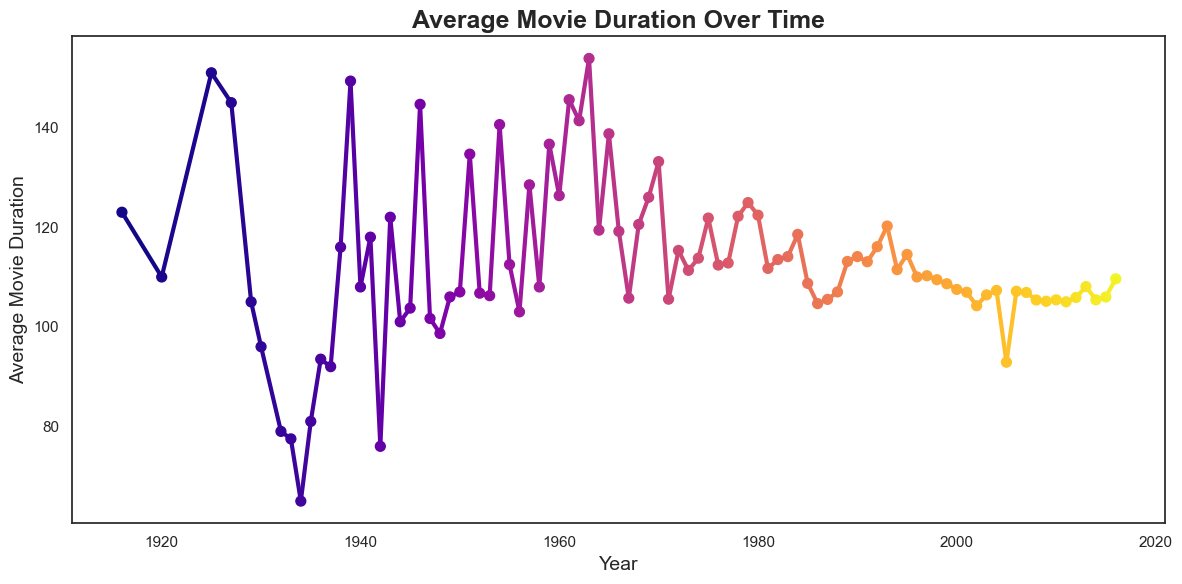

In [299]:
year_avg = (imdb.groupby('title_year')['duration'].mean().reset_index())
sns.set_theme(style="white")
plt.figure(figsize=(12,6))
palette = sns.color_palette("plasma", len(year_avg))
# Plot colorful line with markers
for i in range(len(year_avg)-1):
    plt.plot(year_avg['title_year'][i:i+2],year_avg['duration'][i:i+2],color=palette[i],linewidth=3)
# Add scatter points
plt.scatter(year_avg['title_year'],year_avg['duration'],c=palette,s=50)
plt.title("Average Movie Duration Over Time", fontsize=18, weight='bold')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average Movie Duration", fontsize=14)
plt.tight_layout()
plt.show()

#### Correlation Heatmap

In [326]:
corr_matrix =imdb[numeric_features[1:]].corr()

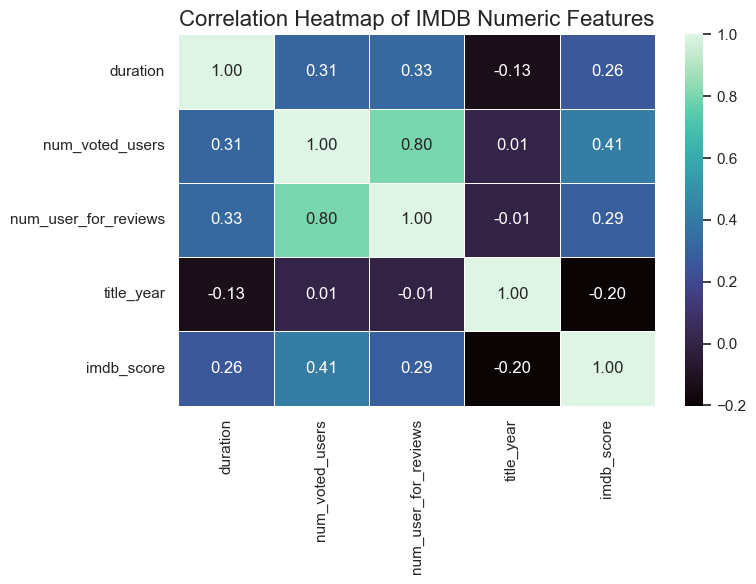

In [328]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="mako",linewidths=0.5)
plt.title("Correlation Heatmap of IMDB Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

<div style="background-color: #e8f5e9; padding: 10px; border-radius: 8px; border-left: 5px solid #2e7d32;">
Engagement metrics show strong internal correlation but only moderate association with IMDb score, indicating that popularity alone does not determine quality. This supports using a hybrid recommendation approach that blends content similarity with engagement-based weighting.

In [390]:
imdb['features'] = (imdb['genres'] + " " +imdb['director_name'] + " " +imdb['actor_1_name'] + " " +imdb['actor_2_name'] + " " +imdb['actor_3_name'])

In [400]:
tfidf = TfidfVectorizer(stop_words='english',max_features=3000,min_df=2,ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(imdb['features'])

In [401]:
tfidf_matrix.nnz

64929

In [402]:
tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])

0.004291691453499901

<div style="background-color: #f0f4f8; padding: 5px; border-radius: 8px; border-left: 5px solid #3498db;">
0.42% of the matrix contains non zero values

In [386]:
feature_names = tfidf.get_feature_names_out()
row = tfidf_matrix[0].toarray().flatten()
top_indices = row.argsort()[-10:][::-1]
for i in top_indices:
    print(feature_names[i], row[i])

studi 0.38928237438472096
pounder 0.3824247078833697
cch 0.3824247078833697
wes 0.3180875473525777
cameron 0.30662773983643116
moore 0.29605595811076896
joel 0.2883102658189332
james 0.20246972858630002
david 0.19346156834399447
fantasy 0.1597618693286901


In [387]:
len(tfidf.get_feature_names_out())

8588

In [377]:
cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1.        , 0.06106735, 0.0331407 , ..., 0.0341801 , 0.        ,
        0.        ],
       [0.06106735, 1.        , 0.0332496 , ..., 0.        , 0.        ,
        0.        ],
       [0.0331407 , 0.0332496 , 1.        , ..., 0.01167064, 0.        ,
        0.        ],
       ...,
       [0.0341801 , 0.        , 0.01167064, ..., 1.        , 0.00588451,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00588451, 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]], shape=(5043, 5043))

In [378]:
def get_recommendations(title, cosine_sim=cosine_sim):
    # Get index of movie
    idx = imdb[imdb['movie_title'] == title].index[0]
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Sort by similarity (highest first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Remove itself and take top 10
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return imdb['movie_title'].iloc[movie_indices]

In [379]:
get_recommendations("Avatar")

455                                  Face/Off
2112                                RoboCop 3
1127                              Deep Rising
306                               End of Days
637                               Mystery Men
2960       Tales from the Crypt: Demon Knight
801     The Mortal Instruments: City of Bones
4426                                  Hatchet
1211                 The Last of the Mohicans
2279                               Undisputed
Name: movie_title, dtype: object